<a href="https://colab.research.google.com/github/Soham86/Projects/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Garbage Classification using CNN

In this notebook, we will build a Convolutional Neural Network to classify garbage images into different waste categories.

The main goal is to understand the full computer vision workflow:

1. Load image dataset
2. Explore folder structure
3. Visualize sample images
4. Create train/validation/test splits
5. Build a CNN model from scratch
6. Train the model
7. Evaluate performance
8. Predict on a new image

## 1. Download / Load Dataset

We are using the Kaggle garbage classification dataset.

The dataset contains images of different garbage categories such as plastic, paper, metal, glass, cardboard, biological waste, batteries, clothes, shoes, and trash.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


# Importing the necessary libraries

we import the necessary for our very first DNN

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Find the Actual Image Folder

Sometimes Kaggle datasets have nested folders.  
So first, we will automatically find the folder that contains class folders.

In [3]:
base_path = Path(path)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def folder_has_images(folder):
    return any(
        file.suffix.lower() in IMAGE_EXTENSIONS
        for file in folder.iterdir()
        if file.is_file()
    )

candidate_dirs = []

for folder in [base_path] + [p for p in base_path.rglob("*") if p.is_dir()]:
    subfolders = [p for p in folder.iterdir() if p.is_dir()]
    image_class_folders = [sub for sub in subfolders if folder_has_images(sub)]

    if len(image_class_folders) >= 2:
        candidate_dirs.append(folder)

print("Candidate dataset folders:")
for folder in candidate_dirs[:5]:
    print(folder)

dataset_dir = candidate_dirs[0]
print("\nUsing dataset directory:", dataset_dir)

Candidate dataset folders:
/kaggle/input/garbage-classification/garbage_classification

Using dataset directory: /kaggle/input/garbage-classification/garbage_classification


## 3. Check Classes

Each folder name represents one class/category.

For example:

- plastic
- paper
- metal
- cardboard
- glass
- trash

In [4]:
class_names = sorted([
    folder.name
    for folder in dataset_dir.iterdir()
    if folder.is_dir()
])

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:")
for cls in class_names:
    print("-", cls)

Number of classes: 12
Classes:
- battery
- biological
- brown-glass
- cardboard
- clothes
- green-glass
- metal
- paper
- plastic
- shoes
- trash
- white-glass


## 4. Count Images in Each Class

Before training, we should check whether the dataset is balanced or imbalanced.

A balanced dataset means each class has a similar number of images.
An imbalanced dataset means some classes have many images while others have very few.

In [5]:
class_counts = {}
for cls in class_names:
  class_folder = dataset_dir/cls
  images = [
      file for file in class_folder.iterdir()
      if file.suffix.lower() in IMAGE_EXTENSIONS
  ]
  class_counts[cls] = len(images)
class_counts

{'battery': 945,
 'biological': 985,
 'brown-glass': 607,
 'cardboard': 891,
 'clothes': 5325,
 'green-glass': 629,
 'metal': 769,
 'paper': 1050,
 'plastic': 865,
 'shoes': 1977,
 'trash': 697,
 'white-glass': 775}

So we can see clearly that dominating classes are clothes ,paper and shoes so our model should have the accuracy higher than base model which has only these images

keep that in mind !!!

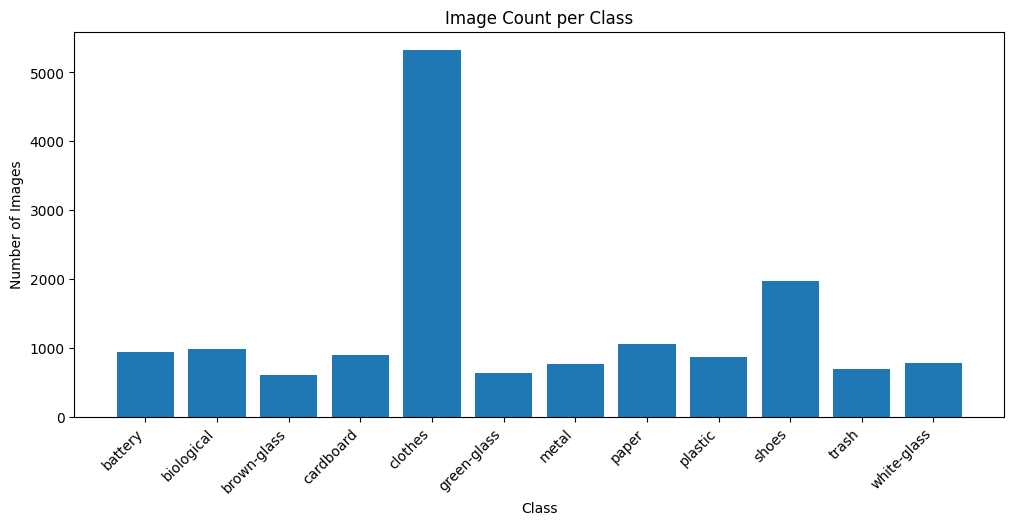

In [6]:
plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(),class_counts.values())
plt.xticks(rotation=45,ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Class")
plt.show()

## 5. Visualize Sample Images

Now we will display some random images from the dataset to understand what the model will see.

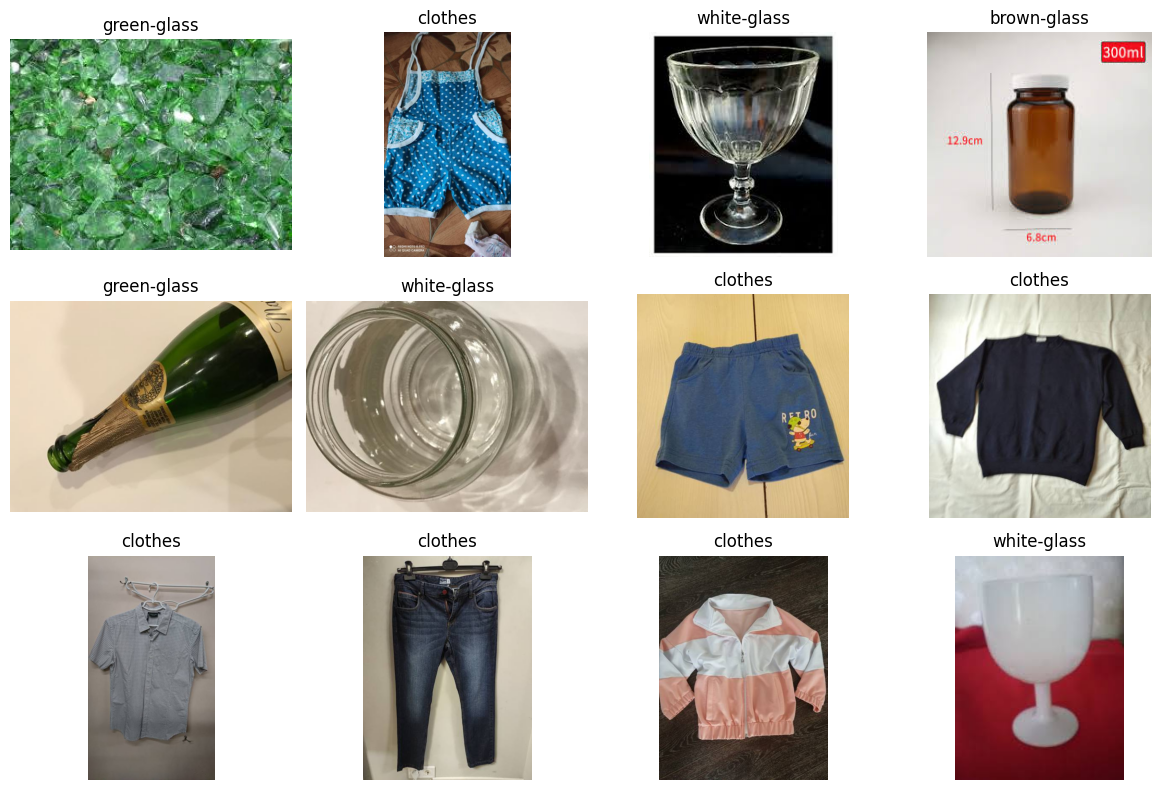

In [7]:
all_images_paths = []

for cls in class_names:
  class_folder = dataset_dir/cls
  for file in class_folder.iterdir():
    if file.suffix.lower() in IMAGE_EXTENSIONS:
      all_images_paths.append((file,cls))
random_samples = random.sample(all_images_paths,12)
plt.figure(figsize=(12,8))


for i,(image_path,label) in enumerate(random_samples):
  img = tf.keras.utils.load_img(image_path) # This function loads image
  # from Disk and converts it into python image library object
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(label)
  plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Prepare Image Paths and Labels

We will convert class names into numbers.

Example:

```text
plastic -> 0
paper -> 1
metal -> 2


---

## Cell 15 — Code: Create image paths and labels

```python
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

image_paths = []
labels = []

for class_name in class_names:
    class_folder = dataset_dir / class_name
    
    for image_file in class_folder.iterdir():
        if image_file.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(str(image_file))
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

In [8]:
class_to_index = {class_name: index for index, class_name in enumerate(class_names)} # Encodes classes to index
index_to_class = {index: class_name for class_name, index in class_to_index.items()} # Encodes back index to Classes

image_paths = [] # Stores something like "datset/cloth/clothes1.jpg"
labels = [] # stores inde like 0,1,2,3 ...

for class_name in class_names:
    class_folder = dataset_dir / class_name # "/" is not divison 😅 its for the path

    for image_file in class_folder.iterdir():
        if image_file.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(str(image_file))
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 15515
Total labels: 15515


## 7. Train / Validation / Test Split

We split the data into three parts:

- Training set: Used to train the model
- Validation set: Used to tune and check model during training
- Test set: Used only at the end for final evaluation

We will use:

- 70% training
- 15% validation
- 15% testing

In [9]:
X_train,X_temp,y_train,y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state = 42,
    stratify = labels
)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
    )
print("Training iamges ", len(X_train))
print("Validation images ", len(X_val))
print("Testing images ", len(X_test))

Training iamges  10860
Validation images  2327
Testing images  2328


## 8. Create TensorFlow Data Pipeline

CNN models need images in a fixed size.

We will resize every image to:

```text
224 x 224


One good practice is to normalize the values of 0-255 so that easy and better to train the network

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.one_hot(label, depth=num_classes)

    return image, label

def create_dataset(image_paths, labels, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=42)

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = create_dataset(X_train, y_train, shuffle=True)
val_ds = create_dataset(X_val, y_val, shuffle=False)
test_ds = create_dataset(X_test, y_test, shuffle=False)


## 9. Check One Batch

Before building the model, we should confirm that our dataset pipeline is working correctly.

In [11]:
for images, labels_batch in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels_batch.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 12)


## 10. Build a Custom CNN Model

A CNN learns visual patterns step by step.

Early layers learn simple features:

```text
edges
corners
colors
textures

```text
later layers learn this features

plastic bottle shape
paper texture
metal can structure
glass reflection

In [12]:
model = models.Sequential([
   layers.Input(shape=(224,224,3)),

   layers.Conv2D(32,(3,3),activation="relu"),
   layers.BatchNormalization(),
   layers.MaxPooling2D((2,2)),

   layers.Conv2D(64,(3,3),activation="relu"),
   layers.BatchNormalization(),
   layers.MaxPooling2D((2,2)),

   layers.Conv2D(128,(3,3),activation="relu"),
   layers.BatchNormalization(),
   layers.MaxPooling2D((2,2)),

   layers.Conv2D(256,(3,3),activation="relu"),
   layers.BatchNormalization(),
   layers.MaxPooling2D((2,2)),

   layers.Flatten(),

   layers.Dense(256,activation="relu"),
   layers.Dropout(0.4),
   layers.Dense(num_classes,activation="softmax"),

])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,830,860 (37.50 MB)

 Trainable params: 9,829,900 (37.50 MB)

 Non-trainable params: 960 (3.75 KB)

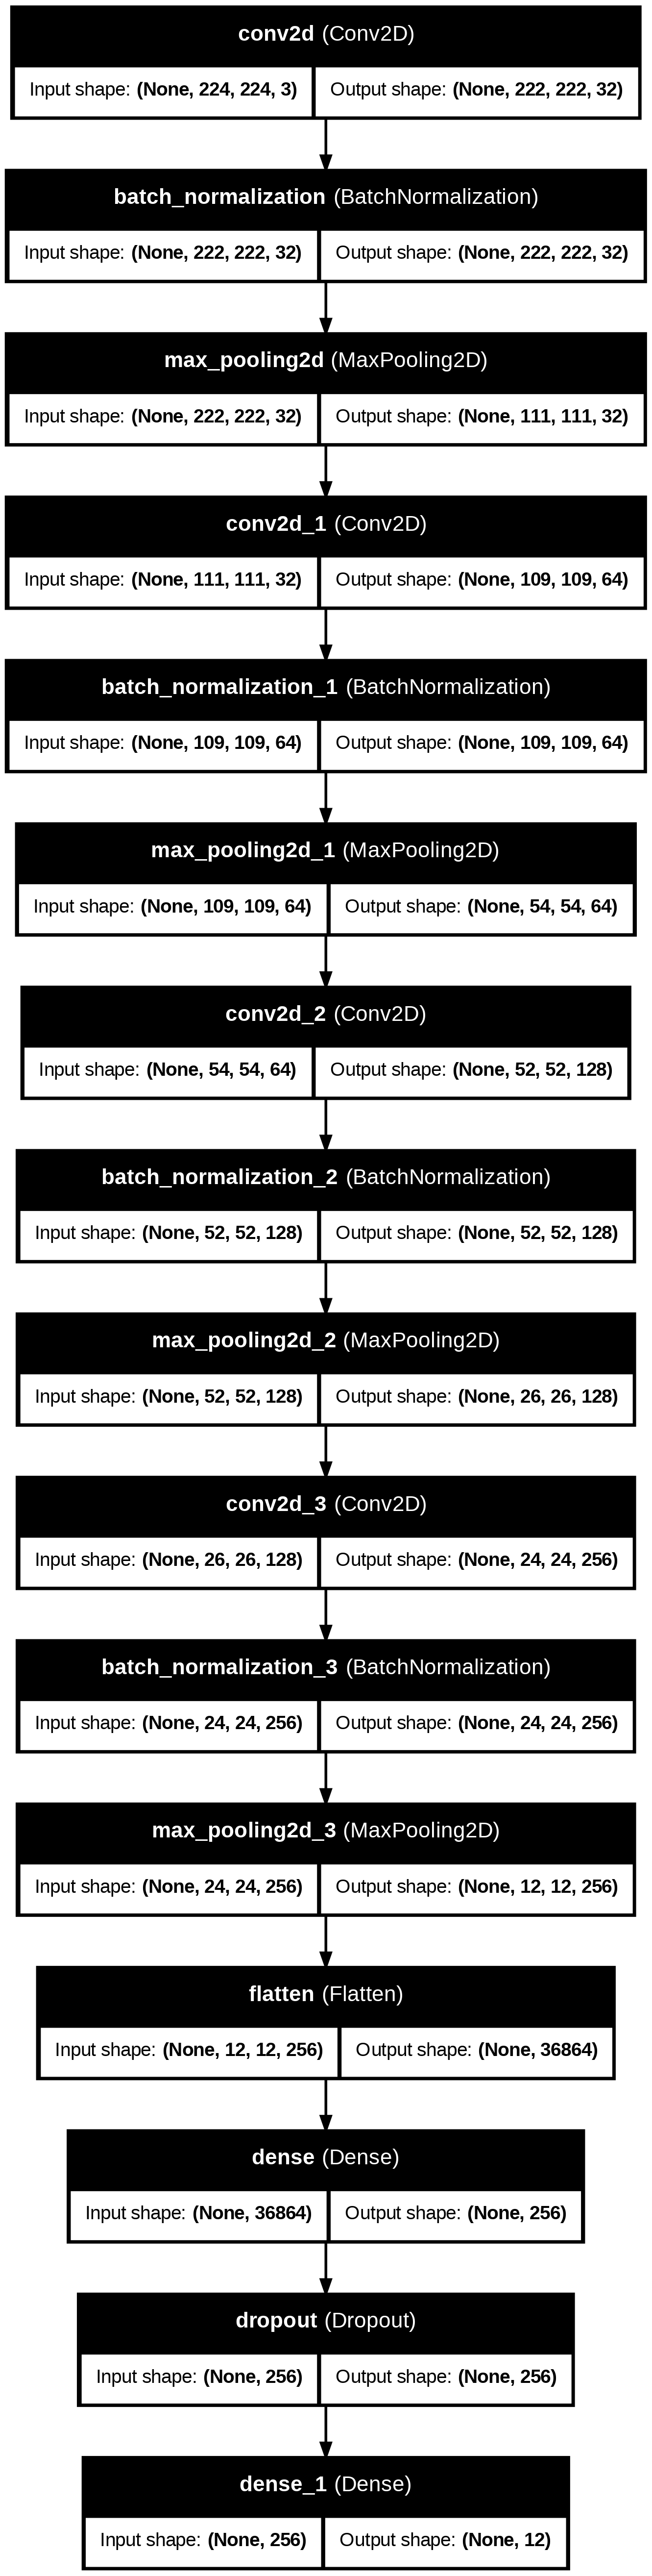

In [13]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True
)

## 11. Compile the Model

We need three things:

1. Optimizer: Controls how the model updates weights
2. Loss function: Measures how wrong the model is
3. Metric: Measures model performance

Since this is a multi-class classification problem, we use:

```text
categorical_crossentropy

In [14]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "categorical_crossentropy",
    metrics=["accuracy"]
)

## 12. Train the Model

We will train the CNN for a few epochs.

An epoch means the model has seen the full training dataset once.

In [21]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_loss",
        save_best_only=True
    )
]
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    callbacks = callbacks
)


Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.7191 - loss: 0.8163 - val_accuracy: 0.4688 - val_loss: 1.8120
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.7341 - loss: 0.7642 - val_accuracy: 0.6102 - val_loss: 1.8281
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.7472 - loss: 0.7373 - val_accuracy: 0.6162 - val_loss: 1.2274
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.7670 - loss: 0.6679 - val_accuracy: 0.6270 - val_loss: 2.1545
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.7744 - loss: 0.6482 - val_accuracy: 0.7228 - val_loss: 1.1480
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.7883 - loss: 0.6070 - val_accuracy: 0.6786 - val_loss: 1.1501
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.7954 - loss: 0.5986 - val_accuracy: 0.6979 - val_loss: 1.6623
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.8094 - loss: 0.5430 - 

## 13. Plot Training Curves

We plot accuracy and loss to understand whether the model is learning properly.

Good sign:

```text
training accuracy increases
validation accuracy increases
training loss decreases
validation loss decreases

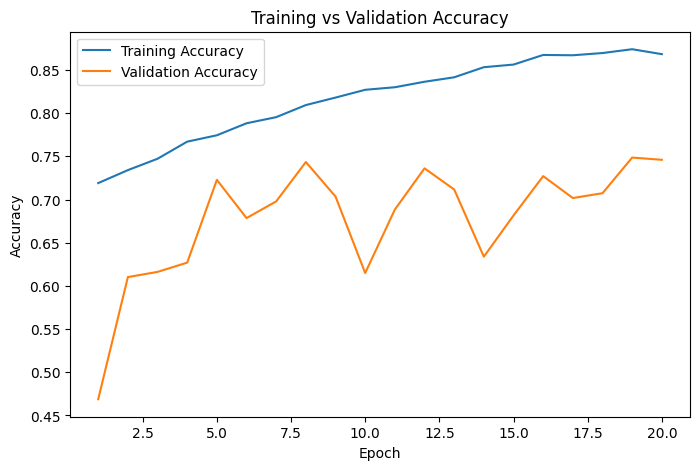

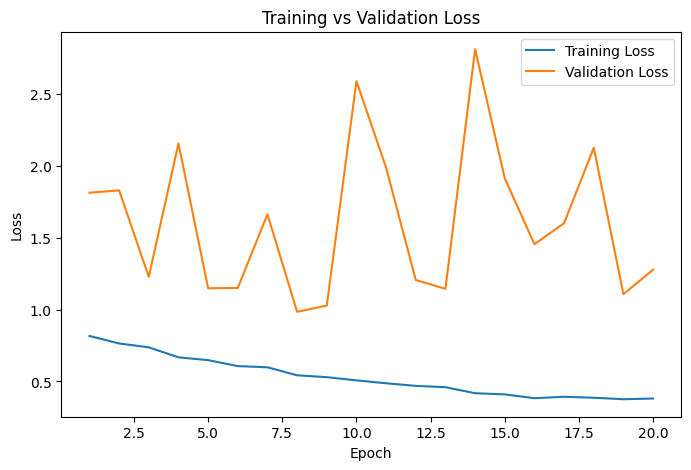

In [22]:

def plot_training_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

plot_training_history(history)

## 14. Evaluate on Test Data

Now we test the model on images it has never seen before.

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7371 - loss: 1.2746
Test Loss: 1.2745904922485352
Test Accuracy: 0.7371134161949158


## 15. Classification Report and Confusion Matrix

Accuracy alone is not enough.

A confusion matrix helps us understand which classes the model is confusing.

For example:

```text
plastic may be confused with glass
paper may be confused with cardboard
trash may be confused with biological

In [25]:
y_true =[]
y_pred = []

for_images = []
for images,labels_batch in test_ds:
  predictions = model.predict(images,verbose=0)
  true_classes = np.argmax(labels_batch.numpy(),axis=1)
  predicted_classes = np.argmax(predictions,axis=1)

  y_true.extend(true_classes)
  y_pred.extend(predicted_classes)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [28]:
print(classification_report(
    y_true,
    y_pred,
    target_names = class_names
))

              precision    recall  f1-score   support

     battery       0.53      0.77      0.63       142
  biological       0.72      0.76      0.74       148
 brown-glass       0.72      0.70      0.71        91
   cardboard       0.87      0.51      0.65       134
     clothes       0.95      0.93      0.94       799
 green-glass       0.77      0.90      0.83        94
       metal       0.29      0.41      0.34       115
       paper       0.77      0.61      0.68       158
     plastic       0.44      0.58      0.50       130
       shoes       0.82      0.66      0.73       297
       trash       0.59      0.74      0.66       104
 white-glass       0.53      0.34      0.42       116

    accuracy                           0.74      2328
   macro avg       0.67      0.66      0.65      2328
weighted avg       0.76      0.74      0.74      2328



<Figure size 1200x1000 with 0 Axes>

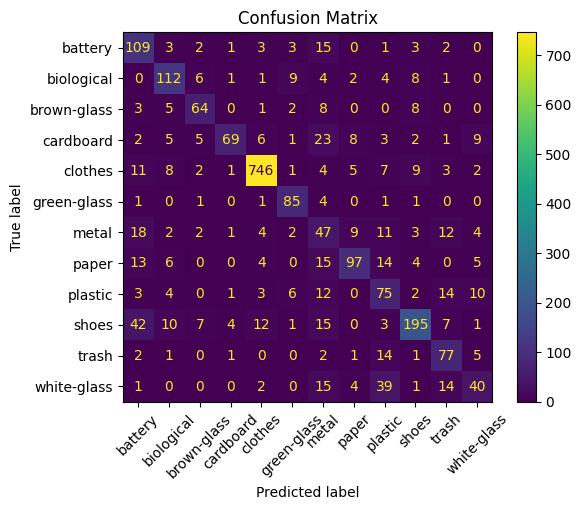

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45, cmap=None)
plt.title("Confusion Matrix")
plt.show()

## 17. Save the Model

We save the trained model so that we can use it later in a Streamlit or FastAPI app.

In [30]:
model.save("garbage_classification_model.keras")
print("Model saved succesfully")

Model saved succesfully


# Real-Time Image Testing using Webcam

Now we will test the trained garbage classifier using a real image captured from the webcam.

Flow:

1. Open webcam
2. Capture one image
3. Preprocess the image exactly like training images
4. Send it to the CNN model
5. Show predicted garbage class and confidence

In [31]:
import json
with open("class_names.json","w") as f:
  json.dump(class_names,f)
print("class names saved")

class names saved


In [33]:
!pip install opencv-python


In [37]:
model = tf.keras.models.load_model("garbage_classification_model.keras")

In [38]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

model = tf.keras.models.load_model("garbage_classification_model.keras")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

index_to_class = {i: class_name for i, class_name in enumerate(class_names)}

IMG_SIZE = (224, 224)

print("Model and class names loaded successfully.")
print(class_names)

Model and class names loaded successfully.
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## Capture One Image from Webcam

This will open your laptop camera, capture one frame, and display it.

This is not continuous video yet.  
First we test one captured image.

<IPython.core.display.Javascript object>

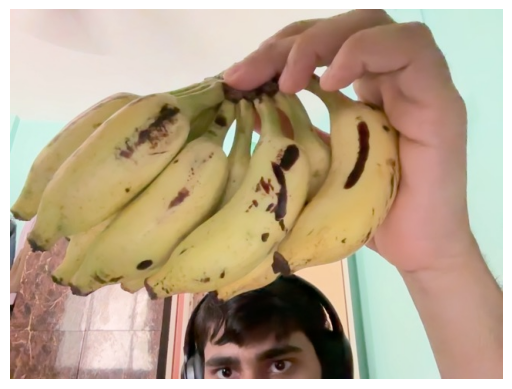

In [47]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
import matplotlib.pyplot as plt

def take_photo(filename="photo.jpg", quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getVideoTracks()[0].stop();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

photo_path = take_photo()

img = cv2.imread(photo_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [48]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(photo_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: biological
